First 5 rows of the dataset:
   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   

                                             content  
0   Quarterly profits at US media giant TimeWarne...  
1   The dollar has hit its highest level against ...  
2   The owners of embattled Russian oil giant Yuk...  
3   British Airways has blamed high fuel prices f...  
4   Shares in UK drinks and food firm Allied Dome...  


Dataset shape (rows, columns):
(2225, 4)


Column names:
['category', 'filename', 'title', 'content']


Missing values per column:
category    0
filename    0
title       0
content     0
dtype: int64


Number of duplicate rows: 0


Number of articles per category:
category
SPORT     

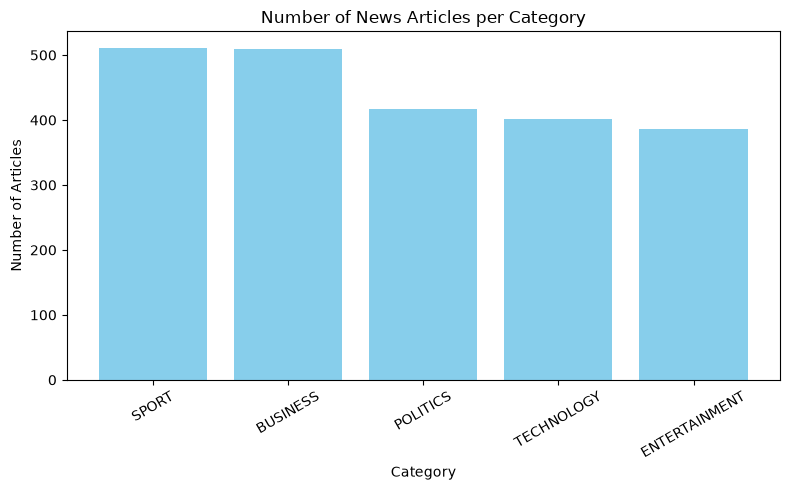

[nltk_data] Downloading package stopwords to C:\Users\Hinal
[nltk_data]     Patel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Hinal
[nltk_data]     Patel\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Hinal
[nltk_data]     Patel\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Columns found in your CSV: ['category', 'filename', 'title', 'content']

Using 'content' as the text column.
Using 'category' as the category column.

Cleaning text... this may take a moment for the full dataset.

BEFORE cleaning (original text, first 300 characters):
 Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fo

AFTER cleaning (clean_text, first 300 characters):
quarterly profit u medium giant timewarner jumped bn three month december yearearlier firm one biggest investor google benefited sale highspeed internet connection higher advert sale timewarner said fourth quarter sale rose bn bn profit buoyed oneoff gain offset profit dip warner bros less user aol 

Number of rows that became empty after cleaning: 0

Cleaned dataset saved to

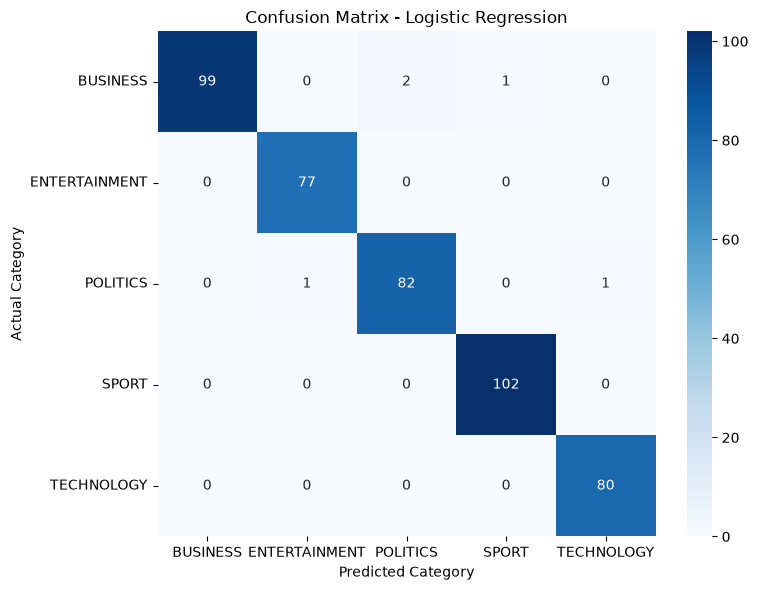


Best model ('Logistic Regression') saved to: artifacts/best_model.pkl
Loading model and artifacts...
Model loaded: Logistic Regression (test accuracy: 98.88%)
Available categories: ['BUSINESS', 'ENTERTAINMENT', 'POLITICS', 'SPORT', 'TECHNOLOGY']

SAMPLE PREDICTIONS

Original text: The prime minister announced new economic reforms during a parliamentary session today.
Predicted category: BUSINESS

Original text: Manchester United secured a dramatic victory in the final minutes of the match.
Predicted category: SPORT

Original text: The latest smartphone features an advanced AI chip and improved battery life.
Predicted category: TECHNOLOGY

Original text: The film won several awards at the ceremony, including best actor and best director.
Predicted category: ENTERTAINMENT

Original text: Stock markets rallied after the central bank announced interest rate cuts.
Predicted category: BUSINESS

TRY YOUR OWN ARTICLE
Type or paste a news article below (or press Enter to skip).



Enter news text:  SpaceX revenue doubled in its first earnings report since its public market debut, driven by satellite and AI growth.



Predicted category: BUSINESS


In [1]:
# ============================================================
# STEP 1: DATASET LOADING - BBC NEWS CATEGORY CLASSIFIER
# ============================================================

# ----- Import required libraries -----
import pandas as pd                 # for loading and handling the dataset
import matplotlib.pyplot as plt     # for plotting the category distribution chart

# ----- Load the dataset -----
# The dataset is expected to be inside the "data" folder of the project.
# It has two columns: "category" (label) and "text" (news article content).

DATA_PATH = r"C:\Users\Hinal Patel\Downloads\bbc-news-data-converted.csv"
df = pd.read_csv(DATA_PATH)

# ----- Display the first five rows -----
# head() lets us quickly inspect the structure of the data.
print("First 5 rows of the dataset:")
print(df.head())
print("\n")

# ----- Display the dataset shape -----
# shape returns (number_of_rows, number_of_columns)
print("Dataset shape (rows, columns):")
print(df.shape)
print("\n")

# ----- Display column names -----
print("Column names:")
print(df.columns.tolist())
print("\n")

# ----- Check for missing values -----
# isnull().sum() counts how many empty/NaN values exist in each column.
print("Missing values per column:")
print(df.isnull().sum())
print("\n")

# ----- Check for duplicate rows -----
# duplicated() flags rows that are exact copies of another row.
# sum() counts how many such duplicate rows exist.
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print("\n")

# ----- Standardize category labels -----
# The raw dataset usually has lowercase category names like:
# 'business', 'entertainment', 'politics', 'sport', 'tech'
# We convert them to uppercase, and rename 'tech' to 'TECHNOLOGY'
# to match the 5 target categories required for this project.
category_mapping = {
    "business": "BUSINESS",
    "entertainment": "ENTERTAINMENT",
    "politics": "POLITICS",
    "sport": "SPORT",
    "tech": "TECHNOLOGY"
}

# .str.lower() ensures matching works even if the CSV has mixed case
df["category"] = df["category"].str.lower().map(category_mapping)

# ----- Display number of articles per category -----
# value_counts() counts how many rows belong to each category.
print("Number of articles per category:")
print(df["category"].value_counts())
print("\n")

# ----- Plot category distribution as a bar chart -----
category_counts = df["category"].value_counts()

plt.figure(figsize=(8, 5))                          # set the figure size
plt.bar(category_counts.index, category_counts.values, color="skyblue")  # bar chart
plt.title("Number of News Articles per Category")   # chart title
plt.xlabel("Category")                               # x-axis label
plt.ylabel("Number of Articles")                     # y-axis label
plt.xticks(rotation=30)                              # rotate labels for readability
plt.tight_layout()                                   # avoid label cutoff
plt.show()                                            # display the chart

# ============================================================
# END OF STEP 1
# ============================================================

# ============================================================
# STEP 2: TEXT PREPROCESSING - BBC NEWS CATEGORY CLASSIFIER
# (Auto-detects column names to avoid KeyError)
# ============================================================

# ----- Import required libraries -----
import pandas as pd          # for loading and handling the dataset
import re                    # for regex-based text cleaning
import nltk                  # for stopwords and lemmatization
from nltk.corpus import stopwords          # list of common "noise" words (the, is, an, etc.)
from nltk.stem import WordNetLemmatizer    # reduces words to their base/root form

# ----- Download required NLTK data (only needed once) -----
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# ----- Load the raw dataset -----
DATA_PATH = r"C:\Users\Hinal Patel\Downloads\bbc-news-data-converted.csv"
df = pd.read_csv(DATA_PATH)

# ----- Print actual column names so we can confirm detection -----
print("Columns found in your CSV:", df.columns.tolist())

# ----- Auto-detect the TEXT column -----
# We check a list of common possible names (case-insensitive) and
# pick the first one that actually exists in your CSV.
possible_text_columns = ["text", "Text", "content", "Content", "article",
                          "Article", "news", "News", "body", "Body"]

text_col = None
for col in possible_text_columns:
    if col in df.columns:
        text_col = col
        break

# ----- Auto-detect the CATEGORY column -----
possible_category_columns = ["category", "Category", "label", "Label",
                              "type", "Type", "class", "Class"]

category_col = None
for col in possible_category_columns:
    if col in df.columns:
        category_col = col
        break

# ----- Stop with a clear message if detection failed -----
if text_col is None or category_col is None:
    raise ValueError(
        f"\n\nCould not auto-detect required columns.\n"
        f"Columns available in your CSV: {df.columns.tolist()}\n"
        f"Detected text column: {text_col}\n"
        f"Detected category column: {category_col}\n"
        f"Please check your CSV headers and update the column names manually."
    )

print(f"\nUsing '{text_col}' as the text column.")
print(f"Using '{category_col}' as the category column.")

# ----- Rename detected columns to standard names -----
# This ensures the rest of the pipeline (Step 3 onward) always sees
# consistent column names: "text" and "category".
df = df.rename(columns={text_col: "text", category_col: "category"})

# ----- Standardize category labels -----
# The raw dataset usually has lowercase category names like:
# 'business', 'entertainment', 'politics', 'sport', 'tech'
category_mapping = {
    "business": "BUSINESS",
    "entertainment": "ENTERTAINMENT",
    "politics": "POLITICS",
    "sport": "SPORT",
    "tech": "TECHNOLOGY",
    "technology": "TECHNOLOGY"
}
df["category"] = df["category"].str.lower().str.strip().map(category_mapping)

# ----- Drop rows where category mapping failed (unexpected label) -----
unmapped = df["category"].isnull().sum()
if unmapped > 0:
    print(f"\nWarning: {unmapped} rows had unrecognized category labels and will be dropped.")
    df = df.dropna(subset=["category"])

# ----- Set up stopwords and lemmatizer -----
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# ----- Define a function to clean a single piece of text -----
def clean_text(text):
    """
    Cleans raw news text by:
    1. Lowercasing all text
    2. Removing punctuation, numbers, and special characters
    3. Removing extra whitespace
    4. Removing stopwords
    5. Lemmatizing remaining words
    """
    # Handle potential missing/non-string values safely
    text = str(text)

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove anything that is NOT a letter or a space
    text = re.sub(r"[^a-z\s]", "", text)

    # 3. Replace multiple spaces/newlines with a single space, then trim edges
    text = re.sub(r"\s+", " ", text).strip()

    # 4. Split the text into individual words (tokens)
    words = text.split()

    # 5. Remove stopwords AND lemmatize each remaining word
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # 6. Join the cleaned words back into a single string
    return " ".join(cleaned_words)


# ----- Apply the cleaning function to every article -----
print("\nCleaning text... this may take a moment for the full dataset.")
df["clean_text"] = df["text"].apply(clean_text)

# ----- Show a before/after example -----
print("\nBEFORE cleaning (original text, first 300 characters):")
print(str(df["text"].iloc[0])[:300])

print("\nAFTER cleaning (clean_text, first 300 characters):")
print(str(df["clean_text"].iloc[0])[:300])

# ----- Check for any empty rows after cleaning -----
empty_after_cleaning = (df["clean_text"].str.strip() == "").sum()
print(f"\nNumber of rows that became empty after cleaning: {empty_after_cleaning}")

# ----- Save the cleaned dataset to a new CSV file -----
OUTPUT_PATH = r"C:\Users\Hinal Patel\Downloads\bbc-news-data-cleaned.csv"
df.to_csv(OUTPUT_PATH, index=False)

print(f"\nCleaned dataset saved to: {OUTPUT_PATH}")
print(f"Final shape of cleaned dataset: {df.shape}")

# ============================================================
# END OF STEP 2
# ============================================================

# ============================================================
# STEP 3: FEATURE EXTRACTION (TF-IDF) - BBC NEWS CLASSIFIER
# ============================================================

# ----- Import required libraries -----
import pandas as pd                                  # for loading and handling the dataset
import numpy as np                                    # for numerical operations
import pickle                                          # for saving Python objects to disk
import os                                              # for creating folders

from sklearn.model_selection import train_test_split          # splits data into train/test sets
from sklearn.feature_extraction.text import TfidfVectorizer    # converts text into TF-IDF numeric features
from sklearn.preprocessing import LabelEncoder                 # converts category names into numbers

# ----- Load the cleaned dataset from Step 2 -----
# This must match the OUTPUT_PATH used at the end of step2_text_preprocessing.py
CLEANED_DATA_PATH = r"C:\Users\Hinal Patel\Downloads\bbc-news-data-cleaned.csv"
df = pd.read_csv(CLEANED_DATA_PATH)

print("Loaded cleaned dataset.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# ----- Drop any rows where clean_text is missing or empty -----
# A blank clean_text row would add noise/errors to the model.
df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.strip() != ""]

print(f"\nShape after removing empty rows: {df.shape}")

# ----- Separate features (X) and target labels (y) -----
X = df["clean_text"]      # the cleaned article text (input to the model)
y = df["category"]        # the category label (what we want to predict)

# ----- Encode category labels into numbers -----
# Machine learning models work with numbers, not text labels.
# LabelEncoder converts e.g. "SPORT" -> 3, "POLITICS" -> 1, etc.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Print the mapping so we know which number corresponds to which category
print("\nLabel encoding mapping:")
for index, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} -> {index}")

# ----- Split data into training and testing sets -----
# 80% of data for training, 20% for testing.
# stratify=y_encoded ensures each category is proportionally represented
# in both the train and test sets (important for balanced evaluation).
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,      # fixed seed so results are reproducible
    stratify=y_encoded
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# ----- Create the TF-IDF Vectorizer -----
# TF-IDF turns text into numeric vectors based on word importance:
# - Frequent words within a document get higher weight (Term Frequency)
# - Words common across ALL documents get lower weight (Inverse Document Frequency)
# max_features: keep only the top 5000 most informative words (limits memory/noise)
# ngram_range=(1,2): consider both single words and two-word phrases (e.g., "prime minister")
# min_df=2: ignore words that appear in fewer than 2 documents (removes rare noise/typos)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

# ----- Fit the vectorizer on TRAINING data only, then transform -----
# We fit only on training data to avoid "data leakage" (the model should
# never see information from the test set during training).
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# ----- Transform the TEST data using the already-fitted vectorizer -----
# We use transform() (not fit_transform()) so the test set is converted
# using the same vocabulary learned from the training set.
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF training matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF testing matrix shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

# ----- Show a few example feature names (words/phrases used as features) -----
sample_features = tfidf_vectorizer.get_feature_names_out()[:20]
print("\nSample TF-IDF features (words/phrases):")
print(sample_features)

# ----- Create the 'artifacts' folder if it doesn't already exist -----
# This folder stores everything Step 4 needs to train the model.
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ----- Save the TF-IDF vectorizer to disk -----
# We need this exact same vectorizer later to transform new/unseen text
# (e.g., when predicting the category of a brand-new article).
with open(os.path.join(ARTIFACTS_DIR, "tfidf_vectorizer.pkl"), "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

# ----- Save the label encoder to disk -----
# Needed later to convert predicted numbers back into category names.
with open(os.path.join(ARTIFACTS_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

# ----- Save the train/test data (features + labels) to disk -----
# Bundling everything into one dictionary keeps Step 4 simple to load.
train_test_data = {
    "X_train": X_train_tfidf,
    "X_test": X_test_tfidf,
    "y_train": y_train,
    "y_test": y_test
}

with open(os.path.join(ARTIFACTS_DIR, "train_test_data.pkl"), "wb") as f:
    pickle.dump(train_test_data, f)

print(f"\nAll artifacts saved successfully in the '{ARTIFACTS_DIR}' folder:")
print("  - tfidf_vectorizer.pkl")
print("  - label_encoder.pkl")
print("  - train_test_data.pkl")

# ============================================================
# END OF STEP 3
# ============================================================

# ============================================================
# STEP 4: MODEL TRAINING - BBC NEWS CATEGORY CLASSIFIER
# ============================================================

# ----- Import required libraries -----
import pickle                                    # for loading/saving Python objects
import os                                         # for file paths
import matplotlib.pyplot as plt                   # for plotting the confusion matrix
import seaborn as sns                             # for a nicer-looking confusion matrix heatmap

from sklearn.naive_bayes import MultinomialNB              # Naive Bayes classifier
from sklearn.linear_model import LogisticRegression        # Logistic Regression classifier
from sklearn.svm import LinearSVC                           # Support Vector Machine classifier
from sklearn.metrics import (
    accuracy_score,        # measures overall correctness
    classification_report, # precision/recall/f1 per category
    confusion_matrix        # shows which categories get confused with which
)

# ----- Load artifacts saved from Step 3 -----
ARTIFACTS_DIR = "artifacts"

# Load the train/test TF-IDF features and labels
with open(os.path.join(ARTIFACTS_DIR, "train_test_data.pkl"), "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

# Load the label encoder (to convert numeric labels back to category names)
with open(os.path.join(ARTIFACTS_DIR, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

print("Loaded training data:", X_train.shape)
print("Loaded testing data:", X_test.shape)
print("Categories:", list(label_encoder.classes_))

# ----- Define the models we want to try -----
# We train three different algorithms and compare their accuracy,
# then keep whichever performs best on the test set.
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42)
}

# ----- Dictionary to store results for comparison -----
results = {}
trained_models = {}

# ----- Train and evaluate each model -----
for model_name, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"Training: {model_name}")
    print(f"{'=' * 60}")

    # Train the model on the TF-IDF training features
    model.fit(X_train, y_train)

    # Predict categories for the test set
    y_pred = model.predict(X_test)

    # Calculate overall accuracy (percentage of correct predictions)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")

    # Print detailed metrics: precision, recall, f1-score per category
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

    # Store this model's results for later comparison
    results[model_name] = accuracy
    trained_models[model_name] = model

# ----- Compare all models and pick the best one -----
print(f"\n{'=' * 60}")
print("MODEL COMPARISON SUMMARY")
print(f"{'=' * 60}")
for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy * 100:.2f}%")

# max(results, key=results.get) finds the dictionary key with the highest value
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]
best_accuracy = results[best_model_name]

print(f"\nBest model: {best_model_name} with {best_accuracy * 100:.2f}% accuracy")

# ----- Plot confusion matrix for the BEST model -----
# A confusion matrix shows how many articles of each true category
# were predicted as each category — helps spot which categories
# get confused with each other (e.g., BUSINESS vs POLITICS).
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,              # show the actual numbers inside each cell
    fmt="d",                 # format numbers as integers
    cmap="Blues",             # color scheme
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.tight_layout()
plt.show()

# ----- Save the best model to disk -----
# This is the file Step 5 (prediction/deployment) will load to make
# predictions on brand-new, unseen news articles.
with open(os.path.join(ARTIFACTS_DIR, "best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

# ----- Also save the best model's name and accuracy for reference -----
model_info = {
    "model_name": best_model_name,
    "accuracy": best_accuracy
}
with open(os.path.join(ARTIFACTS_DIR, "model_info.pkl"), "wb") as f:
    pickle.dump(model_info, f)

print(f"\nBest model ('{best_model_name}') saved to: {ARTIFACTS_DIR}/best_model.pkl")

# ============================================================
# END OF STEP 4
# ============================================================

# ============================================================
# STEP 5: PREDICTION ON NEW/UNSEEN TEXT - BBC NEWS CLASSIFIER
# ============================================================

# ----- Import required libraries -----
import pickle          # for loading saved model/vectorizer/encoder
import os               # for file paths
import re               # for text cleaning (same logic as Step 2)
import nltk             # for stopwords and lemmatization
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ----- Make sure NLTK data is available -----
# (Already downloaded in Step 2, but this ensures it works even if
# this script is run on its own / on a different machine.)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# ----- Set up stopwords and lemmatizer (must match Step 2 exactly) -----
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

ARTIFACTS_DIR = "artifacts"


# ----- Text cleaning function (identical to Step 2) -----
# IMPORTANT: New text must be cleaned the SAME way the training text was,
# otherwise the model will see unfamiliar patterns and predict poorly.
def clean_text(text):
    """
    Cleans raw input text using the same steps as Step 2:
    1. Lowercasing
    2. Removing punctuation/numbers
    3. Removing extra whitespace
    4. Removing stopwords
    5. Lemmatizing
    """
    text = str(text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(cleaned_words)


# ----- Load all saved artifacts -----
def load_artifacts():
    """
    Loads the trained model, TF-IDF vectorizer, and label encoder
    that were saved in Step 3 and Step 4.
    """
    with open(os.path.join(ARTIFACTS_DIR, "tfidf_vectorizer.pkl"), "rb") as f:
        vectorizer = pickle.load(f)

    with open(os.path.join(ARTIFACTS_DIR, "label_encoder.pkl"), "rb") as f:
        encoder = pickle.load(f)

    with open(os.path.join(ARTIFACTS_DIR, "best_model.pkl"), "rb") as f:
        model = pickle.load(f)

    # model_info.pkl just tells us which algorithm was used and its accuracy
    with open(os.path.join(ARTIFACTS_DIR, "model_info.pkl"), "rb") as f:
        info = pickle.load(f)

    return vectorizer, encoder, model, info


# ----- Predict the category of a single piece of text -----
def predict_category(text, vectorizer, encoder, model):
    """
    Takes a raw news article (string), cleans it, converts it to TF-IDF
    features, and returns the predicted category name.
    """
    # 1. Clean the input text exactly like training data was cleaned
    cleaned = clean_text(text)

    # 2. Convert cleaned text into TF-IDF numeric features
    #    NOTE: we use transform(), NOT fit_transform(), because the
    #    vectorizer's vocabulary was already learned during training.
    features = vectorizer.transform([cleaned])

    # 3. Predict the numeric label (e.g., 3)
    predicted_label_num = model.predict(features)[0]

    # 4. Convert the numeric label back into the category name (e.g., "SPORT")
    predicted_category = encoder.inverse_transform([predicted_label_num])[0]

    return predicted_category, cleaned


# ----- Main script logic -----
if __name__ == "__main__":

    # Load everything we need
    print("Loading model and artifacts...")
    tfidf_vectorizer, label_encoder, best_model, model_info = load_artifacts()

    print(f"Model loaded: {model_info['model_name']} "
          f"(test accuracy: {model_info['accuracy'] * 100:.2f}%)")
    print(f"Available categories: {list(label_encoder.classes_)}")

    # ----- Example 1: Test with a few sample articles built into the script -----
    sample_articles = [
        "The prime minister announced new economic reforms during a parliamentary session today.",
        "Manchester United secured a dramatic victory in the final minutes of the match.",
        "The latest smartphone features an advanced AI chip and improved battery life.",
        "The film won several awards at the ceremony, including best actor and best director.",
        "Stock markets rallied after the central bank announced interest rate cuts."
    ]

    print("\n" + "=" * 60)
    print("SAMPLE PREDICTIONS")
    print("=" * 60)

    for article in sample_articles:
        predicted_category, cleaned_version = predict_category(
            article, tfidf_vectorizer, label_encoder, best_model
        )
        print(f"\nOriginal text: {article}")
        print(f"Predicted category: {predicted_category}")

    # ----- Example 2: Let the user type in their own article interactively -----
    print("\n" + "=" * 60)
    print("TRY YOUR OWN ARTICLE")
    print("=" * 60)
    print("Type or paste a news article below (or press Enter to skip).")

    user_input = input("\nEnter news text: ").strip()

    if user_input:
        predicted_category, cleaned_version = predict_category(
            user_input, tfidf_vectorizer, label_encoder, best_model
        )
        print(f"\nPredicted category: {predicted_category}")
    else:
        print("\nNo input provided — skipping user prediction.")

# ============================================================
# END OF STEP 5
# ============================================================

